# SHAP Explainability

1. Fit TreeExplainer on the trained model
2. Global summary plot — top 5 features driving fraud predictions
3. Local force plots for 2-3 correctly-flagged fraud cases
4. Write plain-language explanation of top features

In [36]:
import shap
import joblib
import numpy as np
import pandas as pd

In [37]:
xgb_model = joblib.load('../models/xgb_model.pkl')
X_test = joblib.load("../models/X_test.pkl")

In [38]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)
shap.initjs()

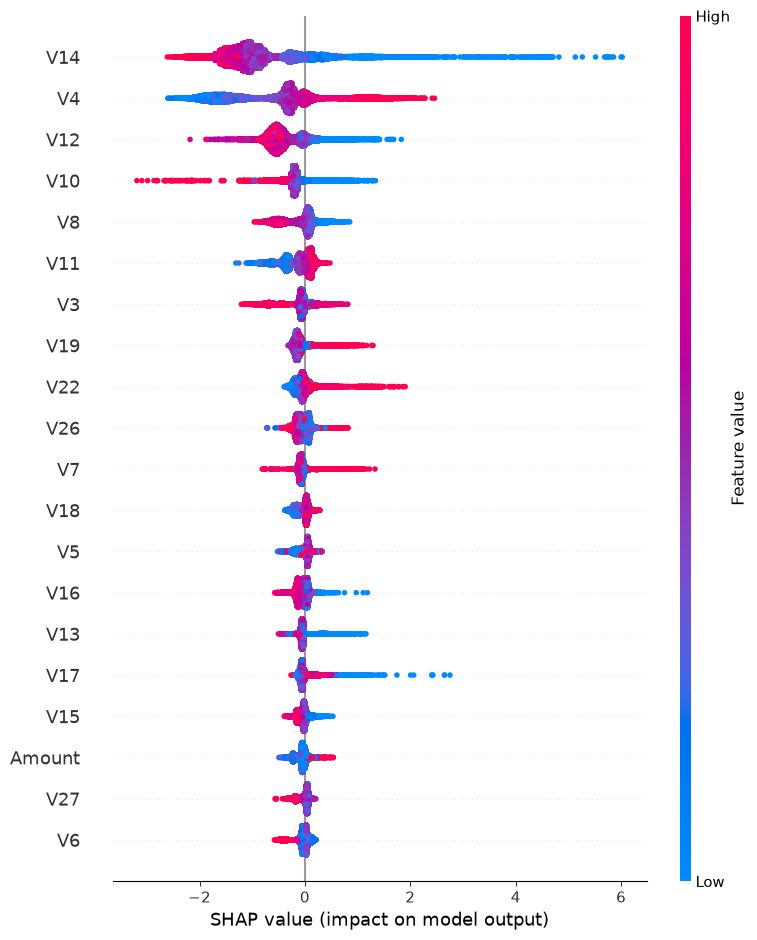

In [39]:
# Summary Plot
shap.summary_plot(shap_values_xgb,X_test)

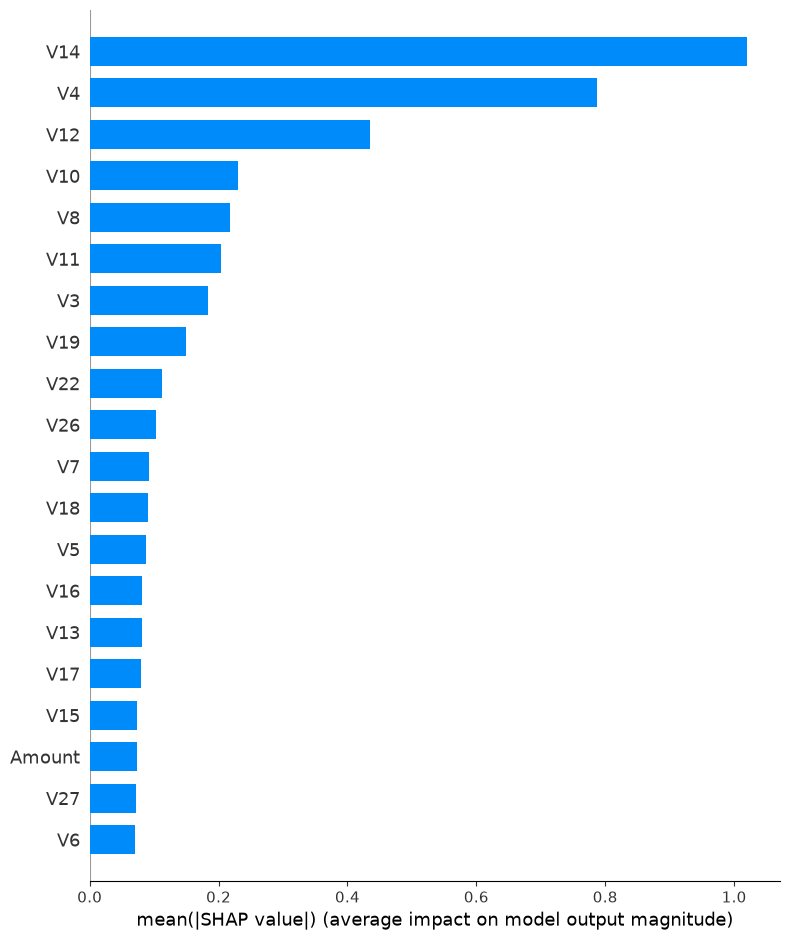

In [40]:
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar")

In [41]:
fraud_predictions = pd.read_csv("../reports/fraud_predictions.csv", index_col=0)

In [42]:
true_positives = fraud_predictions[(fraud_predictions['actual'] == 1) & (fraud_predictions['predicted'] == 1)]

In [43]:
sample_indices = true_positives.index[:3]

--- SHAP Waterfall: True Positive Fraud Case (Index: 116139) ---


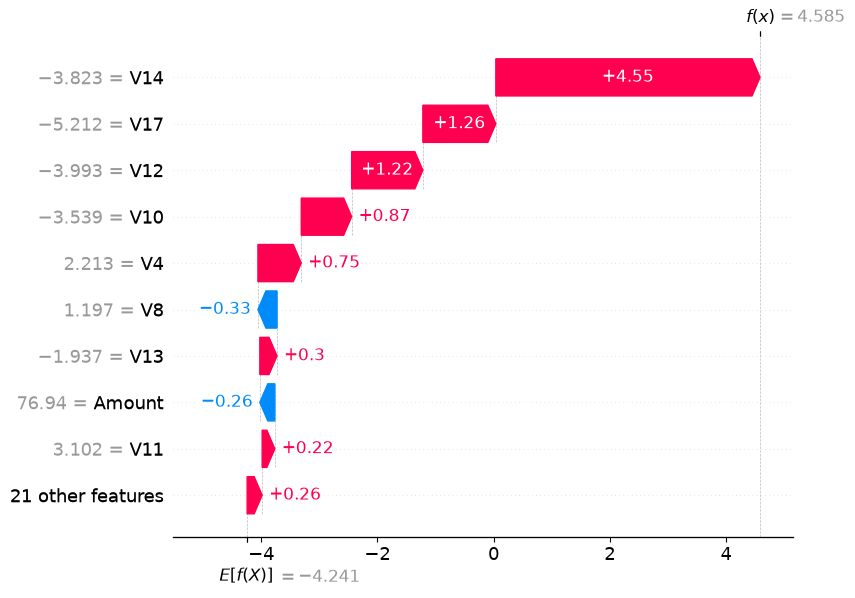

--- SHAP Waterfall: True Positive Fraud Case (Index: 95597) ---


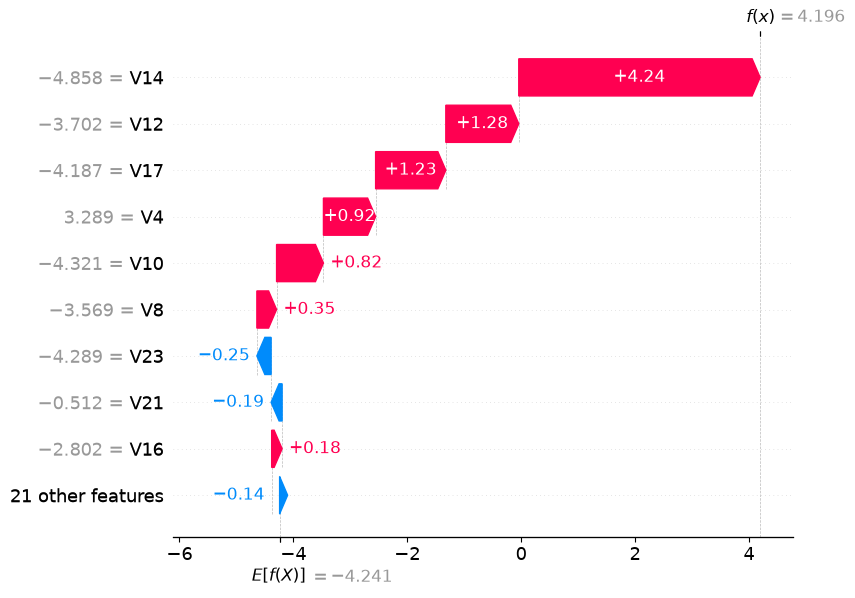

--- SHAP Waterfall: True Positive Fraud Case (Index: 203700) ---


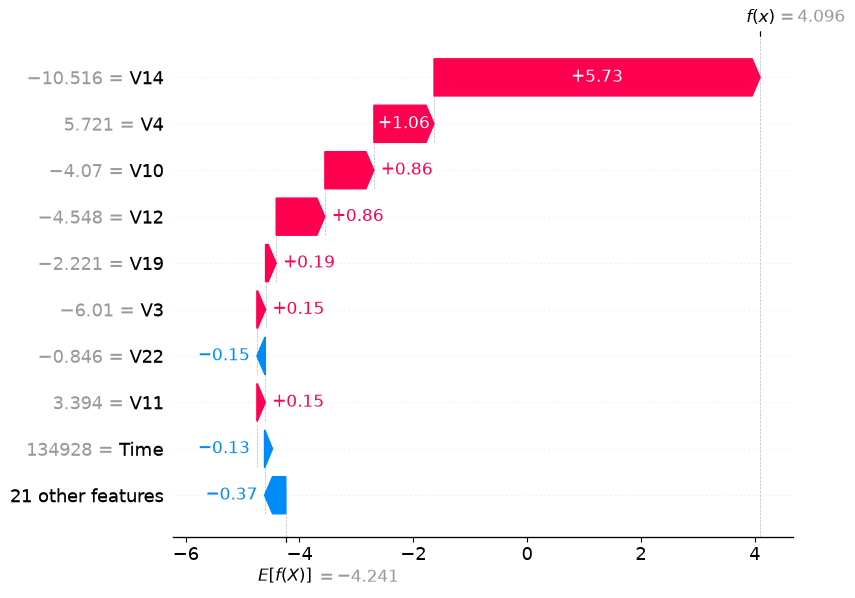

In [44]:
explanation = explainer_xgb(X_test)  # compute once, see #2 below

for idx in sample_indices:
    pos = X_test.index.get_loc(idx)
    print(f"--- SHAP Waterfall: True Positive Fraud Case (Index: {idx}) ---")
    shap.plots.waterfall(explanation[pos])

V14 is the most important feature in all three cases, as it consistently has a strong effect on the model's fraud prediction. V12 and V17 also have a noticeable impact in the first two cases. However, in the third case, their impact is much smaller. This shows that the model does not always rely on the same features when identifying fraudulent transactions. V1-V28 are anonymized PCA components, so there's no real-world label for what V14 represents, but the direction is consistent: in all three cases V14 is strongly negative, and low V14 values push the prediction toward fraud.